In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import optax
import matplotlib.pyplot as plt
import diffrax
from tqdm.notebook import tqdm
import random
import numpy as np

['xy_train', 'alpha_train', 'xy_test']
(10000, 100, 2) (10000, 1)
(10000, 100, 2)


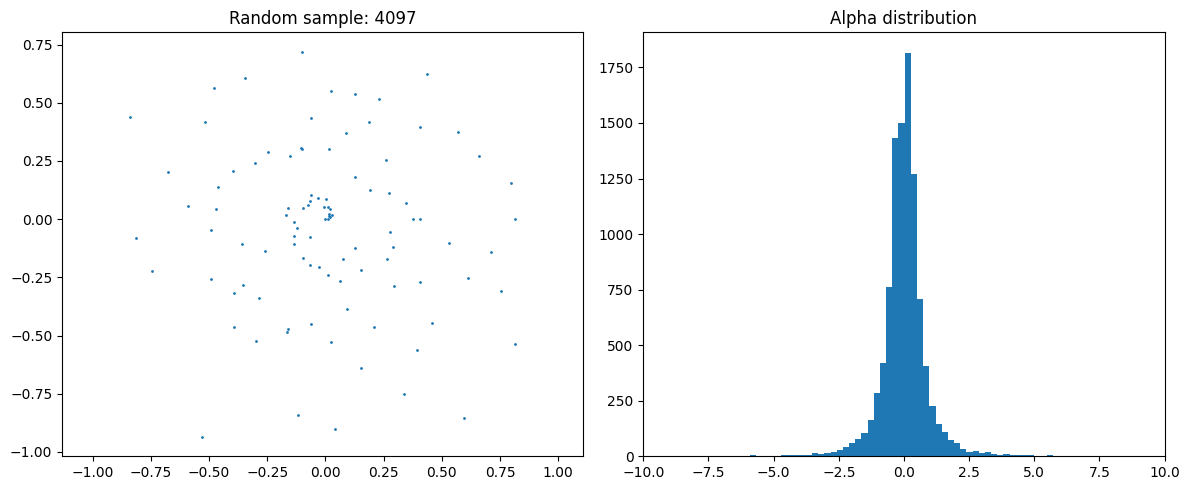

In [2]:
covid_data = jnp.load("spirals.npz")

print(covid_data.files)

xy_train = covid_data["xy_train"]  # (10000, 100, 2)
xy_test = covid_data["xy_test"]  # (10000, 100, 2)
alpha_train = covid_data["alpha_train"]  # (10000, 1)

alpha_mean = jnp.mean(alpha_train)
alpha_std = jnp.std(alpha_train)
alpha_normalized = (alpha_train - alpha_mean) / alpha_std

xy_mean = jnp.mean(xy_train, axis=(0, 1), keepdims=True)
xy_std = jnp.std(xy_train, axis=(0, 1), keepdims=True)
xy_normalized = (xy_train - xy_mean) / xy_std

print(xy_train.shape, alpha_train.shape)
print(xy_test.shape)

rand_idx = random.randint(0, xy_train.shape[0] - 1)
x_train = xy_normalized[rand_idx, :, 0]
y_train = xy_normalized[rand_idx, :, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# scatter of a random training sample
axes[0].scatter(x_train.flatten(), y_train.flatten(), s=1)
axes[0].set_title(f"Random sample: {rand_idx}")
axes[0].axis("equal")

# alpha distribution
axes[1].hist(alpha_normalized.flatten(), bins=100)
axes[1].set_xlim(-10, 10)
axes[1].set_title("Alpha distribution")

plt.tight_layout()
plt.show()

In [3]:
# model
model = eqx.nn.MLP(
    in_size=2 * 100,
    out_size=1,
    width_size=128,
    depth=2,
    activation=jax.nn.relu,
    key=jrandom.PRNGKey(0),
)


@eqx.filter_value_and_grad
def loss_fn(model, x, y, alpha):
    # x, y: (B, T)
    inputs = jnp.concatenate([x, y], axis=-1)  # (B, 200)

    # Apply model sample-wise
    batched_model = eqx.filter_vmap(model)
    preds = batched_model(inputs).squeeze(-1)  # (B,)

    loss = jnp.mean((preds - alpha) ** 2)
    return loss


def get_params(m):
    return eqx.filter(m, eqx.is_inexact_array)


optimizer = optax.adam(1e-3)
opt_state = optimizer.init(get_params(model))
batch_size = 32
epochs = 10

for epoch in range(epochs):
    total_loss = 0.0
    for i in tqdm(range(0, xy_normalized.shape[0], batch_size)):
        x_batch = xy_normalized[i : i + batch_size, :, 0]  # (B, 100)
        y_batch = xy_normalized[i : i + batch_size, :, 1]  # (B, 100)
        alpha_batch = alpha_normalized[i : i + batch_size, 0]  # (B,)

        loss, grads = loss_fn(model, x_batch, y_batch, alpha_batch)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)

        total_loss += loss.item() * x_batch.shape[0]
    avg_loss = total_loss / xy_normalized.shape[0]
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1, Loss: 1.0122


  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 2, Loss: 1.0066


  0%|          | 0/313 [00:00<?, ?it/s]

...

Epoch 8, Loss: 1.0003


  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 9, Loss: 1.0002


  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 10, Loss: 1.0001


Final training MSE: 5.2339
[-0.06103028 -0.0211738  -0.04280002 -0.0547358  -0.01368083 -0.02617029
 -0.02240758 -0.01492134 -0.01117311 -0.01697017]


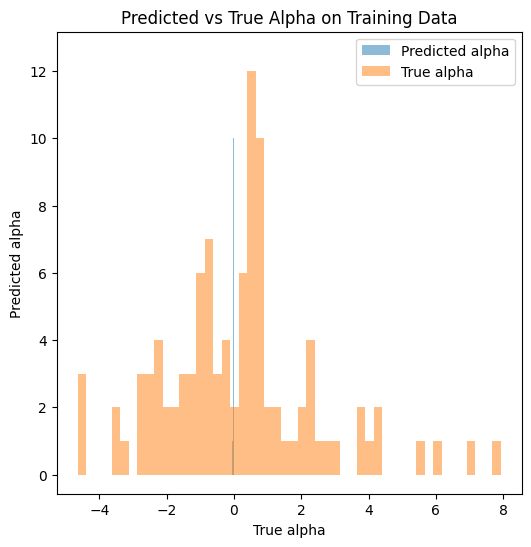

In [4]:
# predictalpha_train
n = 100
test_data = xy_normalized[:n]
alpha_preds = []
for i in range(n):
    x_sample = test_data[i, :, 0:1]  # (100, 1)
    y_sample = test_data[i, :, 1:2]  # (100, 1)
    input_sample = (
        jnp.concatenate([x_sample, y_sample], axis=-1).reshape(1, -1).squeeze()
    )  # (1, 200)
    pred = model(input_sample).squeeze()  # ()
    alpha_preds.append(pred * alpha_std + alpha_mean)


alpha_preds = jnp.array(alpha_preds)  # (N,)
mse_train = jnp.mean((alpha_preds - alpha_train[:n, 0]) ** 2)
print(f"Final training MSE: {mse_train:.4f}")

print(alpha_preds[:10])

# plot predicted vs true alpha
plt.figure(figsize=(6, 6))
plt.hist(alpha_preds, bins=50, alpha=0.5, label="Predicted alpha")
plt.hist(alpha_train[:n, 0], bins=50, alpha=0.5, label="True alpha")
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel("True alpha")
plt.ylabel("Predicted alpha")
plt.title("Predicted vs True Alpha on Training Data")
plt.axis("equal")
plt.legend()
plt.show()